In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

im = Image.open('/home/hieu/Downloads/475746705_1165860411771519_3847217216818638999_n.jpg')
im = np.array(im)
im.shape

(966, 960, 3)

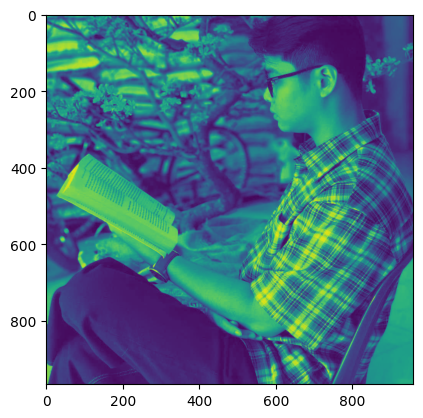

In [10]:
import matplotlib.pyplot as plt

im = np.average(im, axis=2, keepdims=True)
plt.imshow(im)

In [2]:
from deep_learning import *

conv_x = Conv2D(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1)
weight = np.array([[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]])
conv_x.set_weight(weight)
res_x = conv_x(im)
conv_y = Conv2D(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1)
weight = np.array([[[[1, 2, 1], [0, 0, 0], [-1, -2, -1]]]])
conv_y.set_weight(weight)
res_y = conv_y(im)

res = np.sqrt(res_x**2 + res_y**2)

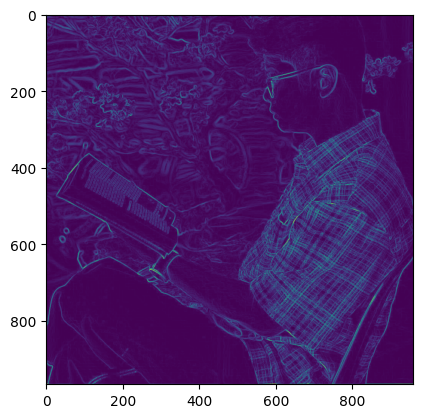

In [4]:
res = res.transpose(1,2,0)
plt.imshow(res)

In [15]:
from deep_learning import *

conv_x = Conv2D(in_channels=1, out_channels=1, kernel_size=99, stride=1, padding=1)
weight = 1/9 * np.ones((1,3,99,99))
conv_x.set_weight(weight)
blur_im = conv_x(im)

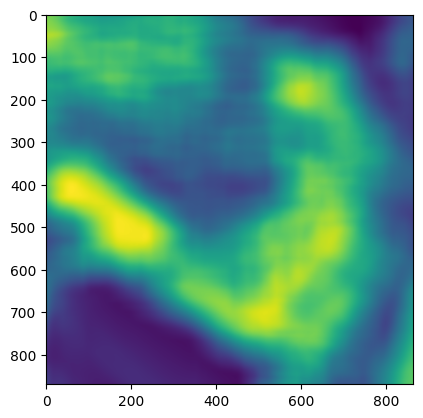

In [16]:
blur_im = blur_im.transpose(1,2,0)
plt.imshow(blur_im)

In [70]:
import math

def gaussian(x, sigma=7):
    return math.exp(-x**2/(2*sigma**2))


k = 15
weights = np.zeros((1,3,k,k))
x_c, y_c = k // 2, k // 2
sum = 0

for y in range(k):
    for x in range(k):
        weights[0, :, y, x] = gaussian(x - x_c) * gaussian(y - y_c)
        sum += weights[0, 0, y, x]

weights = weights / sum


conv_x = Conv2D(in_channels=1, out_channels=1, kernel_size=k, stride=1, padding=1)
conv_x.set_weight(weights)
gaussian_blur_im = conv_x(im)

In [78]:
k = 3
weights = np.zeros((1,3,k,k))
x_c, y_c = k // 2, k // 2
sum = 0

for y in range(k):
    for x in range(k):
        weights[0, :, y, x] = gaussian(x - x_c) * gaussian(y - y_c)
        sum += weights[0, 0, y, x]

conv_x = Conv2D(in_channels=1, out_channels=1, kernel_size=k, stride=1, padding=1)
weights = weights / sum
conv_x.set_weight(weights)
gaussian_blur_im2 = conv_x(im)

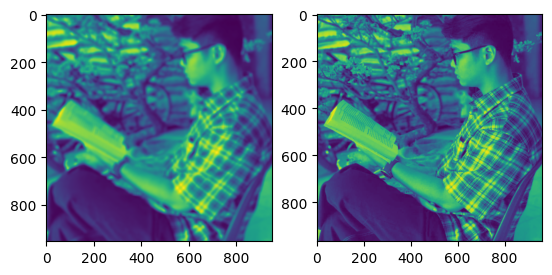

In [79]:
# gaussian_blur_im = gaussian_blur_im.transpose(1,2,0)
gaussian_blur_im2 = gaussian_blur_im2.transpose(1,2,0)
plt.subplot(1,2,1)
plt.imshow(gaussian_blur_im)
plt.subplot(1,2,2)
plt.imshow(gaussian_blur_im2)

In [23]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser" 


df = px.data.tips()

fig = px.density_contour(df, x="total_bill", y="tip")
fig.show()

In [22]:
import nbformat

print(nbformat.__version__)

5.10.4
